In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import rasterio
from rasterio.plot import show
import matplotlib as mpl

In [2]:
survey='KVIOQ'
# survey='3-miippugut'
# survey='3-miippugut-moraine'
# # survey='NMLSFJORD'
# # survey='Paattuulaajiit Ikertivaat'

if survey == 'KVIOQ':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-'+survey+'/files/processed-log-data'
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-08-Kivioq.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-'+survey+'/files/processed-log-figures'
elif survey == '3-miippugut':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-data'
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-02-00_00_2024-08-02-23_59_Sentinel-2_L2A_Highlight_Optimized_Natural_Color_RYBERGS1.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-figures'
elif survey == '3-miippugut-moraine':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-data'    
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-02-00_00_2024-08-02-23_59_Sentinel-2_L2A_Highlight_Optimized_Natural_Color_RYBERGS2.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-figures'
elif survey == 'NMLSFJORD':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-NMLSFJORD/files/processed-log-data'    
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-08-HarissonFjord.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-NMLSFJORD/files/processed-log-figures'
elif survey == 'Paattuulaajiit Ikertivaat':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-CAPEBOWYER/files/processed-log-data'    
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-07-00_00_2024-08-07-23_59_Sentinel-2_L2A_True_color_CB.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-CAPEBOWYER/files/processed-log-figures'
os.makedirs(figdir, exist_ok=True) 




df=pd.read_csv(os.path.join(logdir,'auvdata.csv'))
# convert lat/lon to decimal
latitude=df['Lat']
lat=latitude[latitude.notnull()]
DD=lat/100
DD=DD.astype('int')
SS=lat-DD*100
LatDec = DD + SS/60
latitude[latitude.notnull()]=LatDec
df['Lat']=latitude

longitude=df['Lon']
lon=longitude[longitude.notnull()]
DD=lon/100
DD=DD.astype('int')
SS=lon-DD*100
LonDec = DD + SS/60
longitude[longitude.notnull()]=LonDec
df['Lon']=longitude*-1

if survey == '3-miippugut-moraine':
    df=df.loc[df['Lon'] >= -30.5]
elif survey == '3-miippugut':
    df=df.loc[df['Lon'] <= -30.5]


C:\Users\Marphys\AppData\Local\Temp\ipykernel_105408\4293959682.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latitude[latitude.notnull()]=LatDec
C:\Users\Marphys\AppData\Local\Temp\ipykernel_105408\4293959682.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longitude[longitude.notnull()]=LonDec


In [3]:
list(df)

['Unnamed: 0',
 'timestamp',
 'time-nav',
 'temperature-nav',
 'send-nav-device-data',
 'passthrough-udp-actuator',
 'dead-reckoning-position',
 'dead-reckoning-variance',
 'altitude',
 'dead-reckoning-distance',
 'DRHeading',
 'DRVelocity',
 'DRPitch',
 'DRRoll',
 'DRLat',
 'DRLon',
 'speed',
 'Heading',
 'Pitch',
 'Roll',
 'Depth',
 'Lat',
 'Lon',
 'salinity-nav',
 'water-density',
 'time-gps',
 'UTC',
 'lat',
 'lon',
 'quality',
 'hdop',
 'time-ctd',
 'conductivity',
 'pressure',
 'salinity',
 'sound-velocity',
 'temperature_x',
 'time-aand',
 'air-saturation',
 'c1-amp',
 'c1-r-ph',
 'c2-amp',
 'c2-r-ph',
 'cal-phase',
 'o2-concentration',
 'product-number',
 'raw-temp',
 'serial-number',
 't-c-phase',
 'temperature_y',
 'time-eco',
 'chl-raw',
 'chl-ref',
 'ntu-raw',
 'ntu-ref',
 'thermistor',
 'chl-corrected',
 'ntu-corrected']

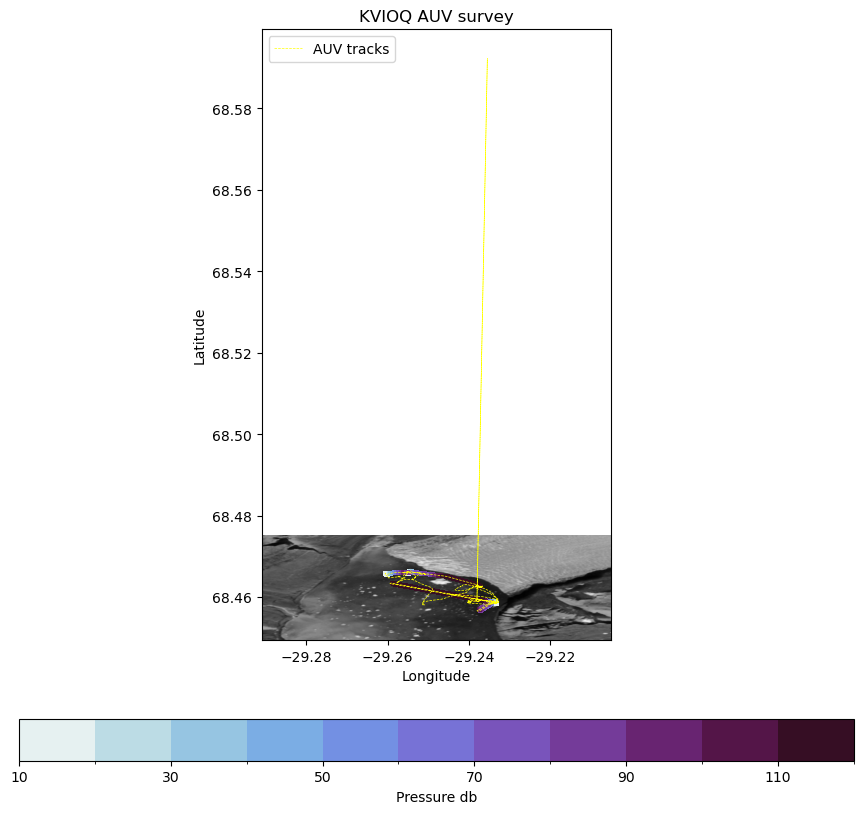

In [4]:
import cmocean

col_list = [
 'Lat',
 'Lon',
 'pressure']
ndf = df[col_list]

# Open the GeoTIFF image
with rasterio.open(geotiff_path) as src:
    img = src.read(1)  # Read the first band
    extent = src.bounds
    crs = src.crs
    transform = src.transform
fig=plt.subplots(figsize=(14, 8),sharex=True, layout='constrained')
plt.imshow(img, cmap='gray', extent=(extent.left, extent.right, extent.bottom, extent.top))
# fig.colorbar(cax1,label='Pixel Values')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Plot the data points
cmap=cmocean.cm.dense
bounds = np.linspace(10, 120, 12)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
h1=plt.scatter(ndf['Lon'], ndf['Lat'], c=ndf['pressure'], s=10,cmap=cmap, marker='s',edgecolor='none', norm=norm)
plt.colorbar(h1,label='Pressure db',shrink=0.6, location='bottom')
h2=plt.plot(ndf['Lon'], ndf['Lat'], color='yellow', linestyle='dashed',
     linewidth=0.5,label='AUV tracks')
plt.title(survey+' AUV survey')
plt.legend(h2,['AUV tracks'])
plt.savefig(os.path.join(figdir,survey+'_survey.png'),bbox_inches='tight', dpi=100)
plt.show()

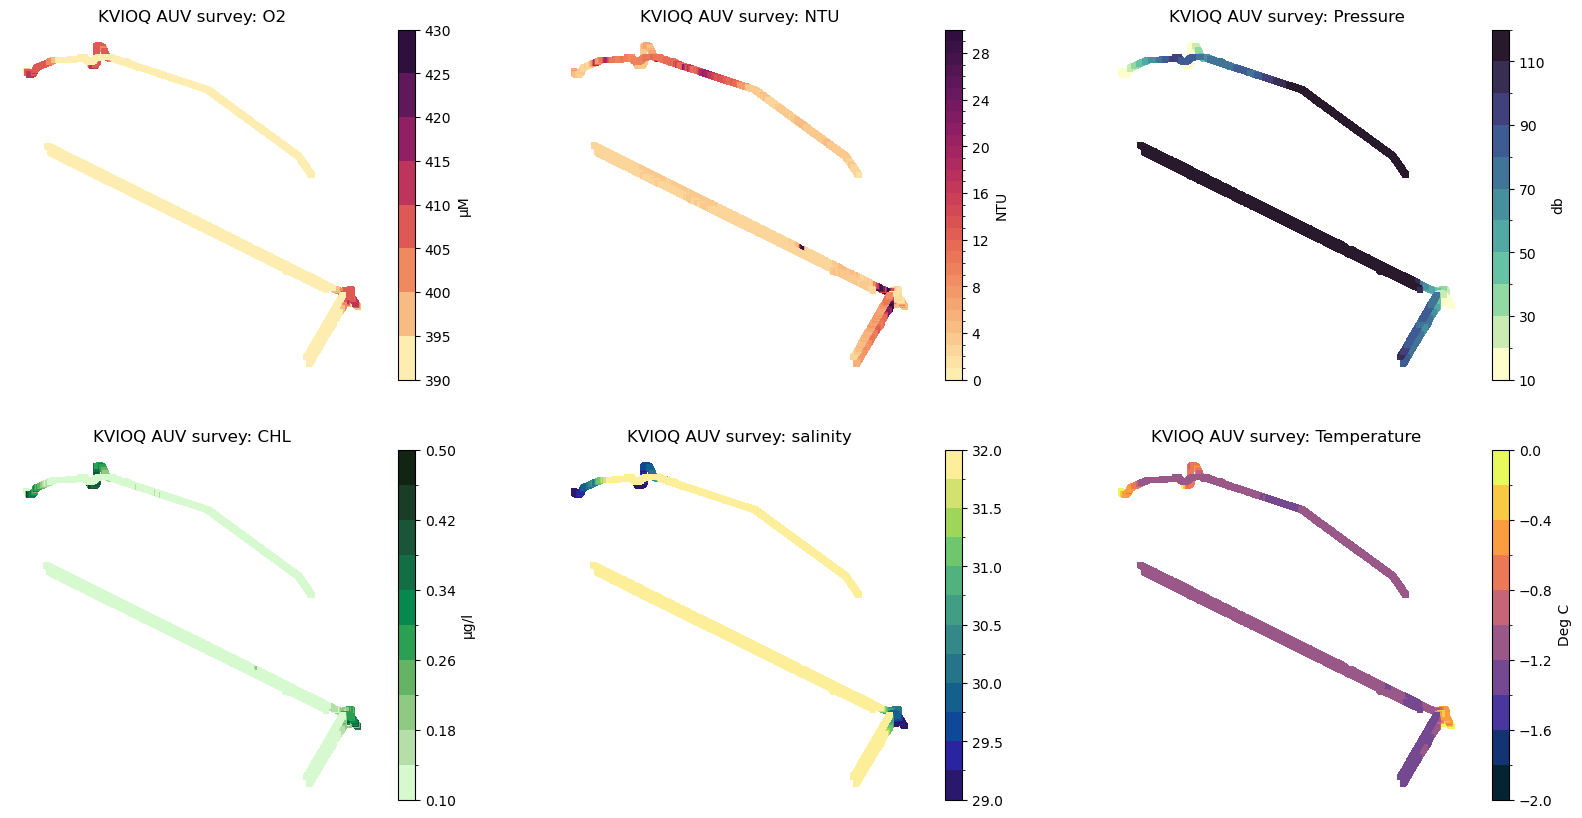

In [5]:
# take only sub 1db pressure data
df=df.loc[df['pressure'] >= 1]

fig, axs = plt.subplots(2,3, figsize=(20, 10))
## ntu
col_list = [
 'Lat',
 'Lon',
 'o2-concentration']
ndf = df[col_list]
# Plot the data points
cmap=cmocean.cm.matter
bounds = np.linspace(390, 430, 9)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cax2=axs[0,0].scatter(ndf['Lon'], ndf['Lat'],
                      c=ndf['o2-concentration'], 
                      s=20,cmap=cmap,
                      norm=norm,
                      marker='s',
                      edgecolor='none')
fig.colorbar(cax2,label='µM')
axs[0, 0].set_title(survey+' AUV survey: O2')

## ntu
col_list = [
 'Lat',
 'Lon',
 'chl-corrected']
ndf = df[col_list]
# Plot the data points
cmap=cmocean.cm.algae
bounds = np.linspace(0.1, 0.5, 11)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cax2=axs[1,0].scatter(ndf['Lon'], ndf['Lat'], c=ndf['chl-corrected'],
                      s=20, 
                      cmap=cmap,
                      norm=norm,
                      marker='s', 
                      edgecolor='none')
fig.colorbar(cax2,label='µg/l')
axs[1, 0].set_title(survey+' AUV survey: CHL')

## CHL
col_list = [
 'Lat',
 'Lon',
 'ntu-corrected']
ndf = df[col_list]
# Plot the data points
cmap=cmocean.cm.matter
bounds = np.linspace(0, 5, 11)
bounds = np.linspace(0, 30, 31)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cax2=axs[0,1].scatter(ndf['Lon'], ndf['Lat'], c=ndf['ntu-corrected'],
                      s=20,
                      cmap=cmap,
                      norm=norm,
                      marker='s', 
                      edgecolor='none')
fig.colorbar(cax2,label='NTU')
axs[0, 1].set_title(survey+' AUV survey: NTU')

## salinity
col_list = [
 'Lat',
 'Lon',
 'salinity']
ndf = df[col_list]
# Plot the data points
cmap=cmocean.cm.haline
bounds = np.linspace(29, 34, 21)
bounds = np.linspace(29, 32, 13)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cax2=axs[1,1].scatter(ndf['Lon'], ndf['Lat'], 
                      c=ndf['salinity'], 
                      s=20,
                      cmap=cmap,
                      norm=norm,
                      marker='s',
                      edgecolor='none')
fig.colorbar(cax2,label='')
axs[1, 1].set_title(survey+' AUV survey: salinity')

## temperature_x
col_list = [
 'Lat',
 'Lon',
 'temperature_x']
ndf = df[col_list]
# Plot the data points
cmap=cmocean.cm.thermal
bounds = np.linspace(-2, 0, 11)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cax2=axs[1,2].scatter(ndf['Lon'], ndf['Lat'], c=ndf['temperature_x'],
                      s=20,
                      cmap=cmap, 
                      norm=norm,
                      marker='s', 
                      edgecolor='none')
fig.colorbar(cax2,label='Deg C')
axs[1, 2].set_title(survey+' AUV survey: Temperature')

## temperature_x
col_list = [
 'Lat',
 'Lon',
 'pressure']
ndf = df[col_list]
# Plot the data points
cmap=cmocean.cm.deep
bounds = np.linspace(10, 120, 12)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cax2=axs[0,2].scatter(ndf['Lon'], ndf['Lat'], c=ndf['pressure'],
                      s=20,
                      cmap=cmap, 
                      norm=norm,
                      marker='s', 
                      edgecolor='none')
fig.colorbar(cax2,label='db')
axs[0, 2].set_title(survey+' AUV survey: Pressure')

axs[0, 0].axis("off")
axs[0, 1].axis("off")
axs[1, 0].axis("off")
axs[1, 1].axis("off")
axs[0, 2].axis("off")
axs[1, 2].axis("off")

plt.savefig(os.path.join(figdir,survey+'_sci_data_overview.png'),bbox_inches='tight', dpi=100)


In [72]:
dist

array([ 878.49280437, 1024.1548401 ])

<>:131: SyntaxWarning: invalid escape sequence '\c'
<>:148: SyntaxWarning: invalid escape sequence '\c'
<>:131: SyntaxWarning: invalid escape sequence '\c'
<>:148: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Marphys\AppData\Local\Temp\ipykernel_105408\3312998314.py:131: SyntaxWarning: invalid escape sequence '\c'
  fig.colorbar(h1,label='MSS: Temperature ($^\circ$C)')
C:\Users\Marphys\AppData\Local\Temp\ipykernel_105408\3312998314.py:148: SyntaxWarning: invalid escape sequence '\c'
  fig.colorbar(h2,label='AUV: Temperature ($^\circ$C)')


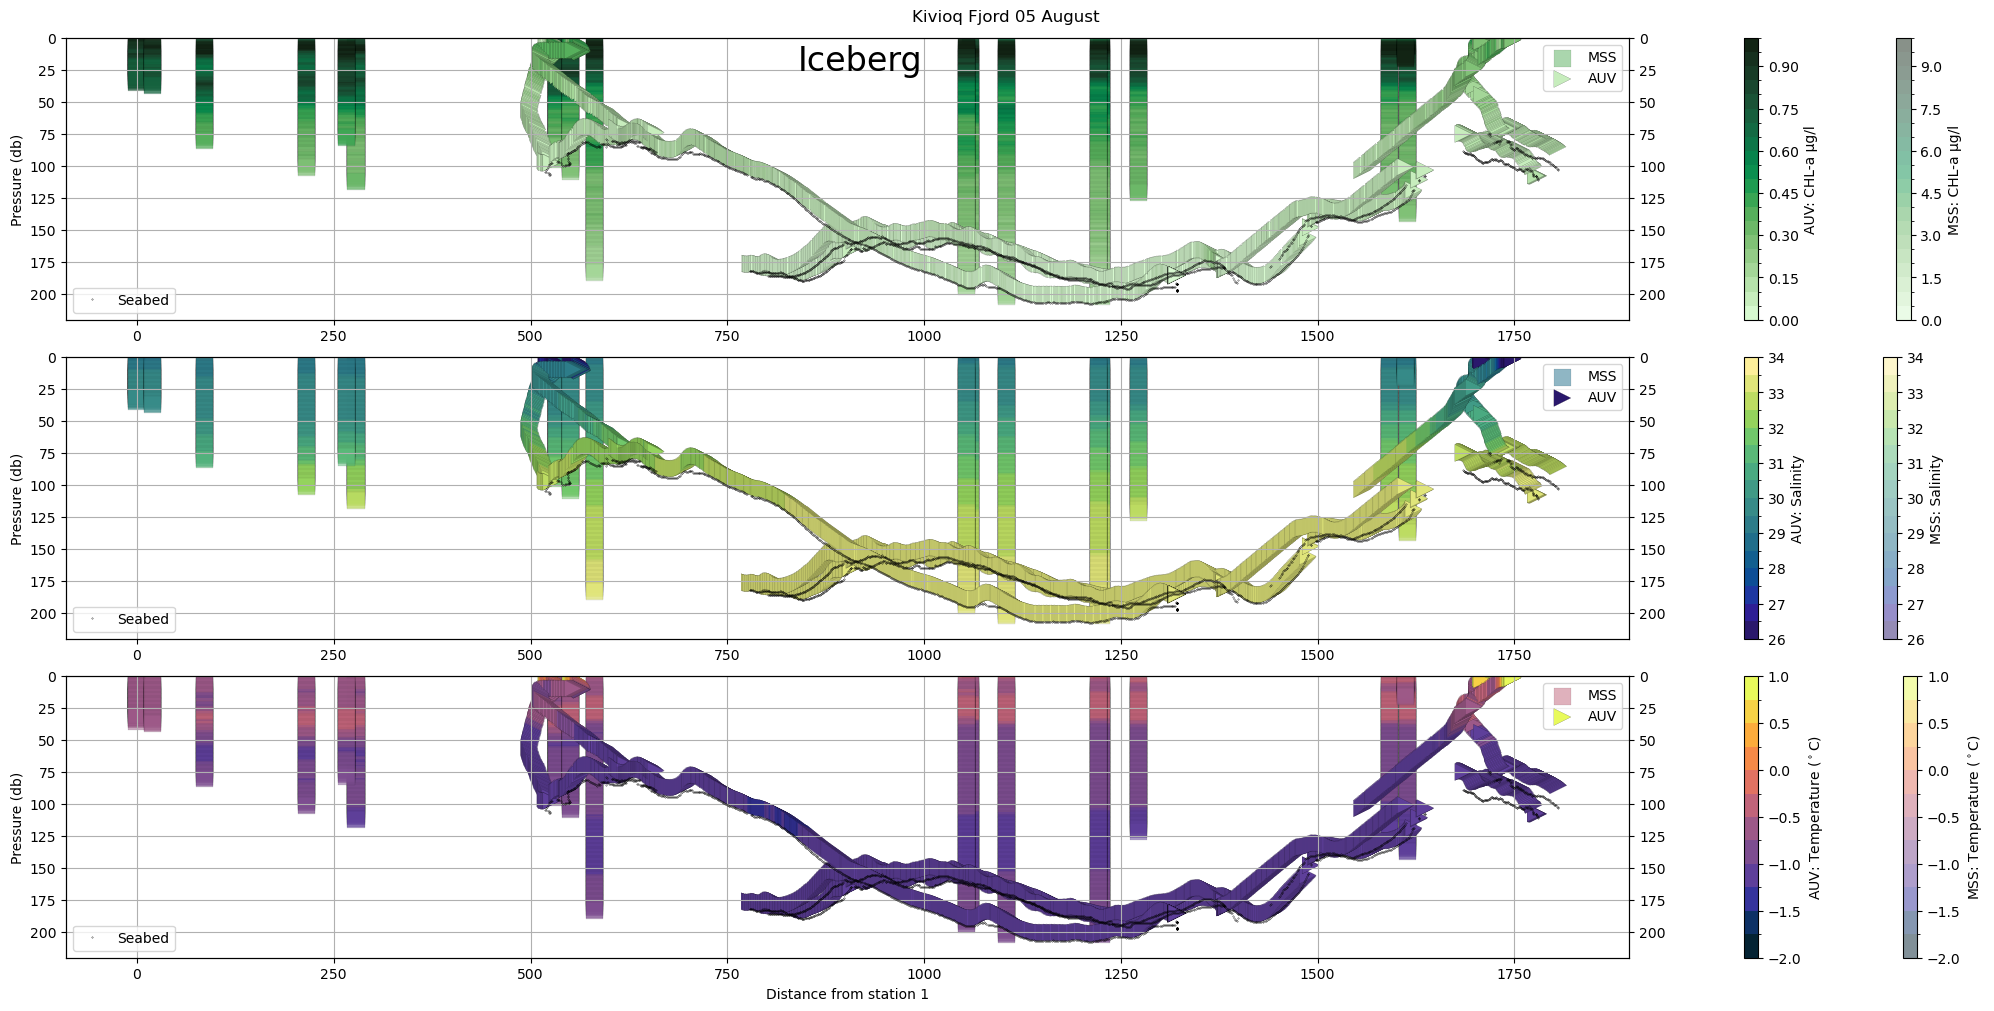

In [95]:
import xarray as xr
import seawater as sw
import gsw

## add in MSS data
mssdta='L:/work/scientific_work_areas/erebus/MSS90-basil/Kivioq_glacierfront/Processed/data_mean.nc'    
mssdta='L:/work/scientific_work_areas/erebus/MSS90-basil/Kivioq_glacierfront/Processed/data.nc'    
ds=xr.open_dataset(mssdta)
lat=ds.lat.values
lon=ds.lon.values
# ## pixk the "start" point - as the first lat/long for MSS
# # the distace betwee this and next will be zero
dist=0
for i in range(21):
    x=np.append(lon[0],lon[i])
    y=np.append(lat[0],lat[i])
    dist=np.append(dist,gsw.distance(x, y, p=0, axis=-1))
    
# mssdist=np.append(0, gsw.distance(lon, lat, p=0, axis=-1))
pres=ds.Press.values
xv, yv = np.meshgrid(dist, pres)

## AUV data 
col_list = [
 'Lat',
 'Lon',
 'pressure',
 'chl-corrected',
 'salinity',
 'temperature_x',
 'Depth',
 'altitude']
ndf = df[col_list]
# insert a row of data with start point of MSS transect
# ndf.loc[-1] = [68.465893,	-29.255243,	np.NaN,	np.NaN,	np.NaN,	np.NaN]  # adding a row
## sort by longitude
ndf=ndf.sort_values(['Lon'])

avdist=[]
for i in range(len(ndf['Lon'])):
    x=np.append(lon[0],ndf.Lon.iloc[i])
    y=np.append(lat[0],ndf.Lat.iloc[i])
    avdist=np.append(avdist,gsw.distance(x, y, p=0, axis=-1))
# Create a distance vector.
# auvdistarry=np.cumsum(np.append(0, gsw.distance(ndf['Lon'], ndf['Lat'], p=0, axis=-1)) )
# auvdistarry=np.append(0, gsw.distance(ndf['Lon'], ndf['Lat'], p=0, axis=-1))

## Add in iceberg
x=np.append(lon[0],-29.25)
y=np.append(lat[0],68.464017)
gdist=gsw.distance(x, y, p=0, axis=-1)
x=np.append(lon[0],-29.244337)
y=np.append(lat[0],68.463536)
gdist=np.append(gdist,gsw.distance(x, y, p=0, axis=-1))

## PLOT DATA
fig, axs = plt.subplots(3,1, figsize=(20, 10), layout="constrained")

## chl a data
z=ds.Chl_A.values
# Plot the data points
cmap=cmocean.cm.algae
bounds = np.linspace(0, 10, 21)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
for i in range(21):
    h1=axs[0].scatter(xv[:,i],yv[:,i],c=z[i,:],s=150, marker="s",alpha=0.5,cmap=cmap, norm=norm,edgecolor="black",linewidth=0.1,
            label='MSS')
fig.colorbar(h1,label='MSS: CHL-a µg/l')
bounds = np.linspace(0, 1, 21)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
h2=axs[0].scatter(avdist,ndf['pressure'],c=ndf['chl-corrected'],marker=">",s=150, edgecolor="black",linewidth=0.1,
            cmap=cmap, 
            norm=norm,
            edgecolors=None,
            label='AUV')
axs[0].set_xlabel("")
axs[0].set_ylabel("Pressure (db)")
fig.colorbar(h2,label='AUV: CHL-a µg/l')
axs[0].grid()
axs[0].legend(handles=[h1,h2])
## add seabed 
ax2 = axs[0].twinx()
depth=ndf['altitude']+ndf['Depth']
ax2.plot(avdist, depth, '.k', markersize=0.5,label = 'Seabed')
ax2.legend(loc=3)
ax2.set_ylim([0, 220])
ax2.invert_yaxis()
axs[0].text(gdist[0],25,'Iceberg',fontsize=24,rotation='horizontal')


## SALINITY a data
z=ds.Sal
# Plot the data points
cmap=cmocean.cm.haline
bounds = np.linspace(26, 34, 17)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
for i in range(21):
    h1=axs[1].scatter(xv[:,i],yv[:,i],c=z[i,:],marker="s",s=150, alpha=0.5,cmap=cmap, norm=norm,edgecolor="black",linewidth=0.1,
            label='MSS')
fig.colorbar(h1,label='MSS: Salinity')
bounds = np.linspace(26, 34, 17)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
h2=axs[1].scatter(avdist,ndf['pressure'],c=ndf['salinity'],marker=">",s=150, edgecolor="black",linewidth=0.1,
            cmap=cmap, 
            norm=norm,
            label='AUV')
axs[1].set_xlabel("")
axs[1].set_ylabel("Pressure (db)")
fig.colorbar(h2,label='AUV: Salinity')
axs[1].grid()
axs[1].legend(handles=[h1,h2])

## add seabed 
ax2 = axs[1].twinx()
depth=ndf['altitude']+ndf['Depth']
ax2.plot(avdist, depth, '.k', markersize=0.5,label = 'Seabed')
ax2.legend(loc=3)
ax2.set_ylim([0, 220])
ax2.invert_yaxis()


## Temp a data
z=ds.Temp
# Plot the data points
cmap=cmocean.cm.thermal
bounds = np.linspace(-2, 1,13)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
for i in range(21):
    h1=axs[2].scatter(xv[:,i],yv[:,i],c=z[i,:],marker="s",s=150, alpha=0.5,cmap=cmap, norm=norm,edgecolor="black",linewidth=0.1,
            label='MSS')
fig.colorbar(h1,label='MSS: Temperature ($^\circ$C)')
bounds = np.linspace(-2, 1, 13)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
h2=axs[2].scatter(avdist,ndf['pressure'],c=ndf['temperature_x'],marker=">",s=150, edgecolor="black",linewidth=0.1,
            cmap=cmap, 
            norm=norm,
            label='AUV')
axs[2].legend(handles=[h1,h2])
## add seabed 
ax2 = axs[2].twinx()
depth=ndf['altitude']+ndf['Depth']
ax2.plot(avdist, depth, '.k', markersize=0.5,label = 'Seabed')
ax2.legend(loc=3)
ax2.set_ylim([0, 220])
ax2.invert_yaxis()
axs[2].set_xlabel("Distance from station 1")
axs[2].set_ylabel("Pressure (db)")
fig.colorbar(h2,label='AUV: Temperature ($^\circ$C)')
axs[2].grid()
fig.suptitle('Kivioq Fjord 05 August')

for i in range(3):
    axs[i].set_ylim([0, 220])
    axs[i].invert_yaxis()

plt.savefig(os.path.join(figdir,survey+'_AUV_vs_MSS_SAL.png'),bbox_inches='tight', dpi=100)
plt.show()

In [96]:
ds

<xarray.Dataset>
Dimensions:         (Press: 199, Station_number: 21, lat: 21, lon: 21)
Coordinates:
  * Press           (Press) float64 4.0 5.0 6.0 7.0 ... 199.0 200.0 201.0 202.0
  * Station_number  (Station_number) int64 1 2 3 4 5 6 7 ... 16 17 18 19 20 21
  * lat             (lat) float64 68.47 68.47 68.47 68.47 ... 68.46 68.46 68.46
  * lon             (lon) float64 -29.26 -29.26 -29.26 ... -29.24 -29.24 -29.24
Data variables: (12/17)
    Eps1            (Station_number, Press) float64 ...
    Temp            (Station_number, Press) float64 -0.4751 -0.5298 ... nan nan
    Eps2            (Station_number, Press) float64 ...
    Cond            (Station_number, Press) float64 ...
    Acc             (Station_number, Press) float64 ...
    Chl_A           (Station_number, Press) float64 8.382 8.902 ... nan nan
    ...              ...
    sig_t           (Station_number, Press) float64 ...
    dens            (Station_number, Press) float64 ...
    BVF             (Station_number, Press) float64 ...
    AS              (Station_number, Press) float64 ...
    CT              (Station_number, Press) float64 ...
    sigma_theta     (Station_number, Press) float64 ...
Attributes:
    data_type:            MSS90
    feature_type:         Profile
    location:             Loch Etive, Scotland
    time:                 August, 2022
    processing_level:     post_processed
    creator_institution:  Scottish Association for Marine Science
    creator_name:         ['Riehn, Lea', 'Inall, Mark']

In [76]:
## Add in Glacier
x=np.append(lon[0],-29.248332)
y=np.append(lat[0],68.464017)
gdist=gsw.distance(x, y, p=0, axis=-1)
x=np.append(lon[0],-29.244337)
y=np.append(lat[0],68.463536)
gdist=np.append(gdist,gsw.distance(x, y, p=0, axis=-1))


In [78]:
gdist[0]

878.4928043704672

In [134]:
avdist=0
for i in range(len(ndf['Lon'])):
    x=np.append(lon[0],ndf.Lon.loc[-1])
    y=np.append(lat[0],ndf.Lat.loc[-1])
    avdist=np.append(avdist,gsw.distance(x, y, p=0, axis=-1))

In [136]:
avdist.shape

(3026,)